In [4]:
import os
import h5py
import librosa
import numpy as np
import json
from concurrent.futures import ThreadPoolExecutor
import random

# --- ÚTVONALAK ---
MP3_DIR = "./MP3/"
H5_PATH = "./Dataset/spotify_dataset.h5"
VALID_JSON = "./valid_cnn_dataset.json"

# --- PARAMÉTEREK ---
FIXED_T = 1280
SR = 22050
DURATION = 30.0

def process_audio_features(args):
    """Egyetlen dal spektrogramjainak kiszámítása"""
    filename, uri, split = args
    path = os.path.join(MP3_DIR, filename)
    
    try:
        # Audió betöltése
        y, _ = librosa.load(path, sr=SR, duration=DURATION)
        if len(y) < SR * DURATION:
            y = librosa.util.fix_length(y, size=int(SR * DURATION))

        # Segédfüggvények (a te logikád alapján)
        def fix_T(arr):
            if arr.shape[1] < FIXED_T:
                return np.pad(arr, ((0,0), (0, FIXED_T - arr.shape[1])), constant_values=0.0)
            return arr[:, :FIXED_T]

        def normalize(arr):
            return ((arr - arr.min()) / (arr.max() - arr.min() + 1e-8)).astype(np.float32)

        # 1. Mel-spektrogram
        mel_raw = librosa.feature.melspectrogram(y=y, sr=SR, n_mels=128, n_fft=2048, hop_length=512)
        mel = fix_T(normalize(librosa.power_to_db(mel_raw, ref=np.max)))

        # 2. Chroma
        chroma_raw = librosa.feature.chroma_cqt(y=y, sr=SR, hop_length=512)
        chroma = fix_T(normalize(chroma_raw))

        # 3. Tempogram
        oenv = librosa.onset.onset_strength(y=y, sr=SR, hop_length=512)
        tempo_raw = librosa.feature.tempogram(onset_envelope=oenv, sr=SR, hop_length=512, win_length=384)
        tempogram = fix_T(normalize(tempo_raw))

        return uri, mel, chroma, tempogram, split, True
    except Exception as e:
        return uri, None, None, None, split, False

if __name__ == "__main__":
    # Adatok betöltése a 27 ezres listából
    with open(VALID_JSON, "r", encoding="utf-8") as f:
        valid_data = json.load(f)
    
    # Feladatok listázása és Split meghatározása (80/10/10)
    items = list(valid_data.items()) # (filename, uri) párok
    random.seed(42)
    random.shuffle(items)

    total = len(items)
    tasks = []
    
    for idx, (fname, uri) in enumerate(items):
        if idx < total * 0.8: split = "train"
        elif idx < total * 0.9: split = "val"
        else: split = "test"
        tasks.append((fname, uri, split))

    print(f"🚀 Indul a nagyüzemi feldolgozás: {total} dal 14-16 szálon...")

    # HDF5 megnyitása
    with h5py.File(H5_PATH, "a") as hf:
        d_mel = hf["spectrograms/mel"]
        d_chr = hf["spectrograms/chroma"]
        d_tem = hf["spectrograms/tempogram"]
        d_uri = hf["ml/track_uri"]
        d_split = hf["ml/split"]

        # 14 szálat használunk, hogy maradjon erőforrás a rendszernek is
        with ThreadPoolExecutor(max_workers=14) as executor:
            batch_size = 100
            for i in range(0, total, batch_size):
                batch = tasks[i : i + batch_size]
                results = list(executor.map(process_audio_features, batch))
                
                for uri, mel, chr, tem, split, success in results:
                    if success:
                        curr = d_uri.shape[0]
                        # Átméretezés
                        d_mel.resize((curr + 1, 128, FIXED_T))
                        d_chr.resize((curr + 1, 12, FIXED_T))
                        d_tem.resize((curr + 1, 384, FIXED_T))
                        d_uri.resize((curr + 1,))
                        d_split.resize((curr + 1,))
                        
                        # Mentés
                        d_mel[curr] = mel
                        d_chr[curr] = chr
                        d_tem[curr] = tem
                        d_uri[curr] = uri
                        d_split[curr] = split
                
                print(f"✨ Haladás: {min(i + batch_size, total)} / {total} dal kész.")
                hf.flush() # Adatok fizikai SSD-re írása

    print(f"\n✅ KÉSZ! A '{H5_PATH}' fájl minden adatot tartalmaz.")

🚀 Indul a nagyüzemi feldolgozás: 27053 dal 14-16 szálon...
✨ Haladás: 100 / 27053 dal kész.
✨ Haladás: 200 / 27053 dal kész.
✨ Haladás: 300 / 27053 dal kész.
✨ Haladás: 400 / 27053 dal kész.
✨ Haladás: 500 / 27053 dal kész.
✨ Haladás: 600 / 27053 dal kész.
✨ Haladás: 700 / 27053 dal kész.
✨ Haladás: 800 / 27053 dal kész.
✨ Haladás: 900 / 27053 dal kész.
✨ Haladás: 1000 / 27053 dal kész.
✨ Haladás: 1100 / 27053 dal kész.
✨ Haladás: 1200 / 27053 dal kész.
✨ Haladás: 1300 / 27053 dal kész.
✨ Haladás: 1400 / 27053 dal kész.
✨ Haladás: 1500 / 27053 dal kész.
✨ Haladás: 1600 / 27053 dal kész.
✨ Haladás: 1700 / 27053 dal kész.
✨ Haladás: 1800 / 27053 dal kész.
✨ Haladás: 1900 / 27053 dal kész.
✨ Haladás: 2000 / 27053 dal kész.
✨ Haladás: 2100 / 27053 dal kész.
✨ Haladás: 2200 / 27053 dal kész.
✨ Haladás: 2300 / 27053 dal kész.
✨ Haladás: 2400 / 27053 dal kész.
✨ Haladás: 2500 / 27053 dal kész.
✨ Haladás: 2600 / 27053 dal kész.
✨ Haladás: 2700 / 27053 dal kész.
✨ Haladás: 2800 / 27053 dal kész

c:\Users\Béres Gábor\music_recommender\.venv\Lib\site-packages\librosa\core\pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


✨ Haladás: 5500 / 27053 dal kész.
✨ Haladás: 5600 / 27053 dal kész.
✨ Haladás: 5700 / 27053 dal kész.
✨ Haladás: 5800 / 27053 dal kész.
✨ Haladás: 5900 / 27053 dal kész.
✨ Haladás: 6000 / 27053 dal kész.
✨ Haladás: 6100 / 27053 dal kész.
✨ Haladás: 6200 / 27053 dal kész.
✨ Haladás: 6300 / 27053 dal kész.
✨ Haladás: 6400 / 27053 dal kész.
✨ Haladás: 6500 / 27053 dal kész.
✨ Haladás: 6600 / 27053 dal kész.
✨ Haladás: 6700 / 27053 dal kész.
✨ Haladás: 6800 / 27053 dal kész.
✨ Haladás: 6900 / 27053 dal kész.
✨ Haladás: 7000 / 27053 dal kész.
✨ Haladás: 7100 / 27053 dal kész.
✨ Haladás: 7200 / 27053 dal kész.
✨ Haladás: 7300 / 27053 dal kész.
✨ Haladás: 7400 / 27053 dal kész.
✨ Haladás: 7500 / 27053 dal kész.
✨ Haladás: 7600 / 27053 dal kész.
✨ Haladás: 7700 / 27053 dal kész.
✨ Haladás: 7800 / 27053 dal kész.
✨ Haladás: 7900 / 27053 dal kész.
✨ Haladás: 8000 / 27053 dal kész.
✨ Haladás: 8100 / 27053 dal kész.
✨ Haladás: 8200 / 27053 dal kész.
✨ Haladás: 8300 / 27053 dal kész.
✨ Haladás: 840

C:\Users\Béres Gábor\AppData\Local\Temp\ipykernel_18920\2321370588.py:26: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(path, sr=SR, duration=DURATION)
c:\Users\Béres Gábor\music_recommender\.venv\Lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


✨ Haladás: 17500 / 27053 dal kész.
✨ Haladás: 17600 / 27053 dal kész.
✨ Haladás: 17700 / 27053 dal kész.
✨ Haladás: 17800 / 27053 dal kész.
✨ Haladás: 17900 / 27053 dal kész.
✨ Haladás: 18000 / 27053 dal kész.
✨ Haladás: 18100 / 27053 dal kész.
✨ Haladás: 18200 / 27053 dal kész.
✨ Haladás: 18300 / 27053 dal kész.
✨ Haladás: 18400 / 27053 dal kész.
✨ Haladás: 18500 / 27053 dal kész.
✨ Haladás: 18600 / 27053 dal kész.
✨ Haladás: 18700 / 27053 dal kész.
✨ Haladás: 18800 / 27053 dal kész.
✨ Haladás: 18900 / 27053 dal kész.
✨ Haladás: 19000 / 27053 dal kész.
✨ Haladás: 19100 / 27053 dal kész.
✨ Haladás: 19200 / 27053 dal kész.
✨ Haladás: 19300 / 27053 dal kész.
✨ Haladás: 19400 / 27053 dal kész.
✨ Haladás: 19500 / 27053 dal kész.
✨ Haladás: 19600 / 27053 dal kész.
✨ Haladás: 19700 / 27053 dal kész.
✨ Haladás: 19800 / 27053 dal kész.
✨ Haladás: 19900 / 27053 dal kész.
✨ Haladás: 20000 / 27053 dal kész.
✨ Haladás: 20100 / 27053 dal kész.
✨ Haladás: 20200 / 27053 dal kész.
✨ Haladás: 20300 / 2

🔍 HDF5 Adatbázis Diagnosztika Indítása...

📊 ADATSZERKEZET MÖGÖTTI MÁTRIXOK:
----------------------------------------
🎵 Mel-spektrogramok: (27052, 128, 1280) | Típus: float32
🎹 Chroma (Akkordok): (27052, 12, 1280) | Típus: float32
🥁 Tempogram (Ritmus): (27052, 384, 1280) | Típus: float32
🔗 URI-k száma:       27052 db

📈 FELOSZTÁS (TRAIN / VAL / TEST):
----------------------------------------
  - Tanító (train):   21642 dal
  - Validációs (val): 2705 dal
  - Teszt (test):     2705 dal

🔬 ADATMINŐSÉG (Az 1. dal vizsgálata):
----------------------------------------
  Mel min érték: 0.0000 (Elvárás: 0.0)
  Mel max érték: 1.0000 (Elvárás: 1.0)
  Mel átlag:     0.6093

🎨 Spektrogram kirajzolása egy új ablakban...


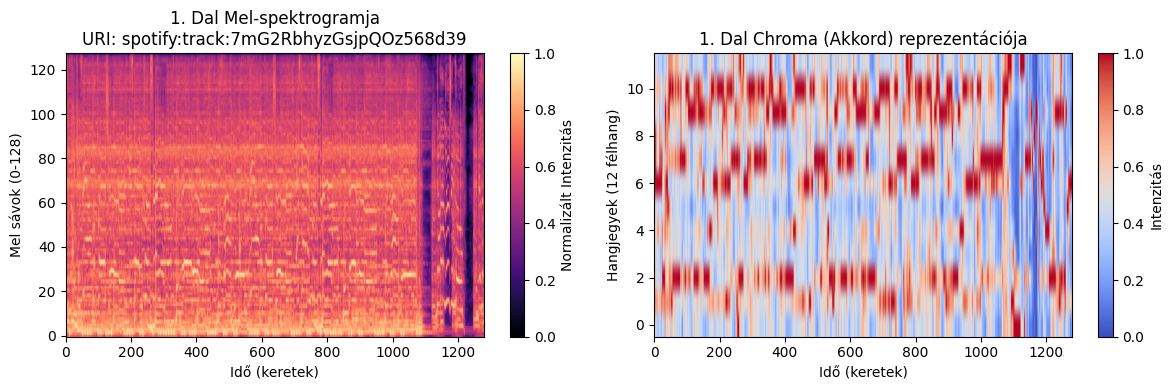

In [3]:
import h5py
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

H5_PATH = "./Dataset/spotify_dataset.h5"

print("🔍 HDF5 Adatbázis Diagnosztika Indítása...\n")

with h5py.File(H5_PATH, "r") as hf:
    # 1. Alapvető méretek és típusok
    print("📊 ADATSZERKEZET MÖGÖTTI MÁTRIXOK:")
    print("-" * 40)
    mel = hf["spectrograms/mel"]
    chroma = hf["spectrograms/chroma"]
    tempo = hf["spectrograms/tempogram"]
    uri = hf["ml/track_uri"]
    split = hf["ml/split"]
    
    total_songs = mel.shape[0]
    
    print(f"🎵 Mel-spektrogramok: {mel.shape} | Típus: {mel.dtype}")
    print(f"🎹 Chroma (Akkordok): {chroma.shape} | Típus: {chroma.dtype}")
    print(f"🥁 Tempogram (Ritmus): {tempo.shape} | Típus: {tempo.dtype}")
    print(f"🔗 URI-k száma:       {uri.shape[0]} db")
    
    # 2. Split statisztika (Mennyi ment a tanításhoz?)
    print("\n📈 FELOSZTÁS (TRAIN / VAL / TEST):")
    print("-" * 40)
    splits_data = [s.decode('utf-8') if isinstance(s, bytes) else s for s in split[:]]
    counts = Counter(splits_data)
    print(f"  - Tanító (train):   {counts.get('train', 0)} dal")
    print(f"  - Validációs (val): {counts.get('val', 0)} dal")
    print(f"  - Teszt (test):     {counts.get('test', 0)} dal")
    
    # 3. Adatminőség ellenőrzése (Nincsenek-e tele nullákkal?)
    print("\n🔬 ADATMINŐSÉG (Az 1. dal vizsgálata):")
    print("-" * 40)
    first_mel = mel[0]
    print(f"  Mel min érték: {np.min(first_mel):.4f} (Elvárás: 0.0)")
    print(f"  Mel max érték: {np.max(first_mel):.4f} (Elvárás: 1.0)")
    print(f"  Mel átlag:     {np.mean(first_mel):.4f}")
    
    # 4. Lássuk a képet!
    print("\n🎨 Spektrogram kirajzolása egy új ablakban...")
    plt.figure(figsize=(12, 4))
    
    # Mel-spektrogram
    plt.subplot(1, 2, 1)
    plt.imshow(first_mel, aspect='auto', origin='lower', cmap='magma')
    plt.title(f"1. Dal Mel-spektrogramja\nURI: {uri[0].decode('utf-8') if isinstance(uri[0], bytes) else uri[0]}")
    plt.colorbar(label="Normalizált Intenzitás")
    plt.ylabel("Mel sávok (0-128)")
    plt.xlabel("Idő (keretek)")
    
    # Chroma
    plt.subplot(1, 2, 2)
    plt.imshow(chroma[0], aspect='auto', origin='lower', cmap='coolwarm')
    plt.title("1. Dal Chroma (Akkord) reprezentációja")
    plt.colorbar(label="Intenzitás")
    plt.ylabel("Hangjegyek (12 félhang)")
    plt.xlabel("Idő (keretek)")
    
    plt.tight_layout()
    plt.show()

🔍 HDF5 Adatbázis Diagnosztika Indítása...

📊 ADATSZERKEZET MÖGÖTTI MÁTRIXOK:
----------------------------------------
🎵 Mel-spektrogramok: (27052, 128, 1280) | Típus: float16
🎹 Chroma (Akkordok): (27052, 12, 1280) | Típus: float16
🥁 Tempogram (Ritmus): (27052, 384, 1280) | Típus: float16
🔗 URI-k száma:       27052 db

📈 FELOSZTÁS (TRAIN / VAL / TEST):
----------------------------------------
  - Tanító (train):   21642 dal
  - Validációs (val): 2705 dal
  - Teszt (test):     2705 dal

🔬 ADATMINŐSÉG (Az 1. dal vizsgálata):
----------------------------------------
  Mel min érték: 0.0000 (Elvárás: 0.0)
  Mel max érték: 1.0000 (Elvárás: 1.0)
  Mel átlag:     0.6094

🎨 Spektrogram kirajzolása egy új ablakban...


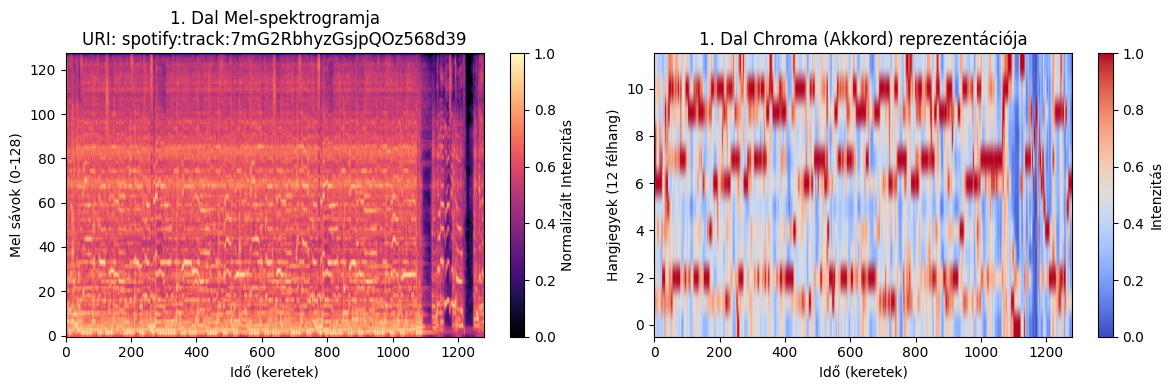

In [7]:
import h5py
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

H5_PATH = "./Dataset/spotify_dataset_compressed.h5"

print("🔍 HDF5 Adatbázis Diagnosztika Indítása...\n")

with h5py.File(H5_PATH, "r") as hf:
    # 1. Alapvető méretek és típusok
    print("📊 ADATSZERKEZET MÖGÖTTI MÁTRIXOK:")
    print("-" * 40)
    mel = hf["spectrograms/mel"]
    chroma = hf["spectrograms/chroma"]
    tempo = hf["spectrograms/tempogram"]
    uri = hf["ml/track_uri"]
    split = hf["ml/split"]
    
    total_songs = mel.shape[0]
    
    print(f"🎵 Mel-spektrogramok: {mel.shape} | Típus: {mel.dtype}")
    print(f"🎹 Chroma (Akkordok): {chroma.shape} | Típus: {chroma.dtype}")
    print(f"🥁 Tempogram (Ritmus): {tempo.shape} | Típus: {tempo.dtype}")
    print(f"🔗 URI-k száma:       {uri.shape[0]} db")
    
    # 2. Split statisztika (Mennyi ment a tanításhoz?)
    print("\n📈 FELOSZTÁS (TRAIN / VAL / TEST):")
    print("-" * 40)
    splits_data = [s.decode('utf-8') if isinstance(s, bytes) else s for s in split[:]]
    counts = Counter(splits_data)
    print(f"  - Tanító (train):   {counts.get('train', 0)} dal")
    print(f"  - Validációs (val): {counts.get('val', 0)} dal")
    print(f"  - Teszt (test):     {counts.get('test', 0)} dal")
    
    # 3. Adatminőség ellenőrzése (Nincsenek-e tele nullákkal?)
    print("\n🔬 ADATMINŐSÉG (Az 1. dal vizsgálata):")
    print("-" * 40)
    first_mel = mel[0]
    print(f"  Mel min érték: {np.min(first_mel):.4f} (Elvárás: 0.0)")
    print(f"  Mel max érték: {np.max(first_mel):.4f} (Elvárás: 1.0)")
    print(f"  Mel átlag:     {np.mean(first_mel):.4f}")
    
    # 4. Lássuk a képet!
    print("\n🎨 Spektrogram kirajzolása egy új ablakban...")
    plt.figure(figsize=(12, 4))
    
    # Mel-spektrogram
    plt.subplot(1, 2, 1)
    plt.imshow(first_mel, aspect='auto', origin='lower', cmap='magma')
    plt.title(f"1. Dal Mel-spektrogramja\nURI: {uri[0].decode('utf-8') if isinstance(uri[0], bytes) else uri[0]}")
    plt.colorbar(label="Normalizált Intenzitás")
    plt.ylabel("Mel sávok (0-128)")
    plt.xlabel("Idő (keretek)")
    
    # Chroma
    plt.subplot(1, 2, 2)
    plt.imshow(chroma[0], aspect='auto', origin='lower', cmap='coolwarm')
    plt.title("1. Dal Chroma (Akkord) reprezentációja")
    plt.colorbar(label="Intenzitás")
    plt.ylabel("Hangjegyek (12 félhang)")
    plt.xlabel("Idő (keretek)")
    
    plt.tight_layout()
    plt.show()

In [6]:
import h5py
import numpy as np

OLD_H5 = "./Dataset/spotify_dataset.h5"
NEW_H5 = "./Dataset/spotify_dataset_compressed.h5"

print("🗜️ HDF5 Tömörítés és Float16 Konverzió Indítása...")

with h5py.File(OLD_H5, 'r') as hf_old, h5py.File(NEW_H5, 'w') as hf_new:

    total = hf_old["spectrograms/mel"].shape[0]
    print(f"🎵 Összesen {total} dal másolása és tömörítése...\n")

    # --- 1. EREDETI CSOPORTOK ÁTMÁSOLÁSA (tracks, playlists, playlist_tracks) ---
    for group in ["tracks", "playlists", "playlist_tracks"]:
        if group in hf_old:
            hf_old.copy(group, hf_new)
            print(f"✅ '{group}' csoport átmásolva.")

    # --- 2. ÚJ CSOPORTOK LÉTREHOZÁSA ---
    hf_new.create_group("spectrograms")
    hf_new.create_group("ml")

    # --- 3. SPEKTROGRAM DATASETEK LÉTREHOZÁSA (FLOAT16 + LZF) ---
    d_mel_new = hf_new.create_dataset(
        "spectrograms/mel", shape=(total, 128, 1280), dtype='float16',
        compression='lzf', chunks=(1, 128, 1280)
    )
    d_chr_new = hf_new.create_dataset(
        "spectrograms/chroma", shape=(total, 12, 1280), dtype='float16',
        compression='lzf', chunks=(1, 12, 1280)
    )
    d_tem_new = hf_new.create_dataset(
        "spectrograms/tempogram", shape=(total, 384, 1280), dtype='float16',
        compression='lzf', chunks=(1, 384, 1280)
    )

    # --- 4. ML METAADATOK ÁTMÁSOLÁSA ---
    hf_new.create_dataset("ml/track_uri", data=hf_old["ml/track_uri"][:])
    hf_new.create_dataset("ml/split",     data=hf_old["ml/split"][:])
    print("✅ 'ml/track_uri' és 'ml/split' átmásolva.")

    # --- 5. SPEKTROGRAMOK BATCH-ENKÉNTI KONVERTÁLÁSA ---
    batch_size = 500
    for i in range(0, total, batch_size):
        end = min(i + batch_size, total)

        d_mel_new[i:end] = hf_old["spectrograms/mel"][i:end].astype('float16')
        d_chr_new[i:end] = hf_old["spectrograms/chroma"][i:end].astype('float16')
        d_tem_new[i:end] = hf_old["spectrograms/tempogram"][i:end].astype('float16')

        print(f"  ✨ {end}/{total} dal konvertálva.")

# --- 6. ELLENŐRZÉS ---
print("\n📊 Ellenőrzés...")
with h5py.File(NEW_H5, 'r') as hf:
    print(f"  Spektrogramok:     {hf['spectrograms/mel'].shape[0]:,} dal")
    print(f"  Mel dtype:         {hf['spectrograms/mel'].dtype}")
    print(f"  Tracks:            {hf['tracks/track_uri'].shape[0]:,} egyedi dal")
    print(f"  Playlists:         {hf['playlists/pid'].shape[0]:,} lejátszási lista")

import os
old_gb = os.path.getsize(OLD_H5) / 1e9
new_gb = os.path.getsize(NEW_H5) / 1e9
print(f"\n  Eredeti méret:  {old_gb:.1f} GB")
print(f"  Új méret:       {new_gb:.1f} GB")
print(f"  Megtakarítás:   {(1 - new_gb/old_gb)*100:.1f}%")

print(f"\n🎉 Kész! Az új fájl: {NEW_H5}")

🗜️ HDF5 Tömörítés és Float16 Konverzió Indítása...
🎵 Összesen 27052 dal másolása és tömörítése...

✅ 'tracks' csoport átmásolva.
✅ 'playlists' csoport átmásolva.
✅ 'playlist_tracks' csoport átmásolva.
✅ 'ml/track_uri' és 'ml/split' átmásolva.
  ✨ 500/27052 dal konvertálva.
  ✨ 1000/27052 dal konvertálva.
  ✨ 1500/27052 dal konvertálva.
  ✨ 2000/27052 dal konvertálva.
  ✨ 2500/27052 dal konvertálva.
  ✨ 3000/27052 dal konvertálva.
  ✨ 3500/27052 dal konvertálva.
  ✨ 4000/27052 dal konvertálva.
  ✨ 4500/27052 dal konvertálva.
  ✨ 5000/27052 dal konvertálva.
  ✨ 5500/27052 dal konvertálva.
  ✨ 6000/27052 dal konvertálva.
  ✨ 6500/27052 dal konvertálva.
  ✨ 7000/27052 dal konvertálva.
  ✨ 7500/27052 dal konvertálva.
  ✨ 8000/27052 dal konvertálva.
  ✨ 8500/27052 dal konvertálva.
  ✨ 9000/27052 dal konvertálva.
  ✨ 9500/27052 dal konvertálva.
  ✨ 10000/27052 dal konvertálva.
  ✨ 10500/27052 dal konvertálva.
  ✨ 11000/27052 dal konvertálva.
  ✨ 11500/27052 dal konvertálva.
  ✨ 12000/27052 da

In [2]:
pip install librosa

  Using cached librosa-0.11.0-py3-none-any.whl.metadata (8.7 kB)
  Using cached audioread-3.1.0-py3-none-any.whl.metadata (9.0 kB)
  Using cached soundfile-0.13.1-py2.py3-none-win_amd64.whl.metadata (16 kB)
  Using cached pooch-1.9.0-py3-none-any.whl.metadata (10 kB)
  Using cached soxr-1.0.0-cp312-abi3-win_amd64.whl.metadata (5.6 kB)
  Using cached lazy_loader-0.5-py3-none-any.whl.metadata (5.9 kB)
  Using cached msgpack-1.1.2-cp312-cp312-win_amd64.whl.metadata (8.4 kB)
  Using cached cffi-2.0.0-cp312-cp312-win_amd64.whl.metadata (2.6 kB)
  Using cached pycparser-3.0-py3-none-any.whl.metadata (8.2 kB)
Using cached librosa-0.11.0-py3-none-any.whl (260 kB)
Using cached audioread-3.1.0-py3-none-any.whl (23 kB)
Using cached lazy_loader-0.5-py3-none-any.whl (8.0 kB)
Using cached msgpack-1.1.2-cp312-cp312-win_amd64.whl (72 kB)
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ------------------- -------------------- 1.3/2.7 MB 13.4 MB/s eta 0:00:01
   -----------------

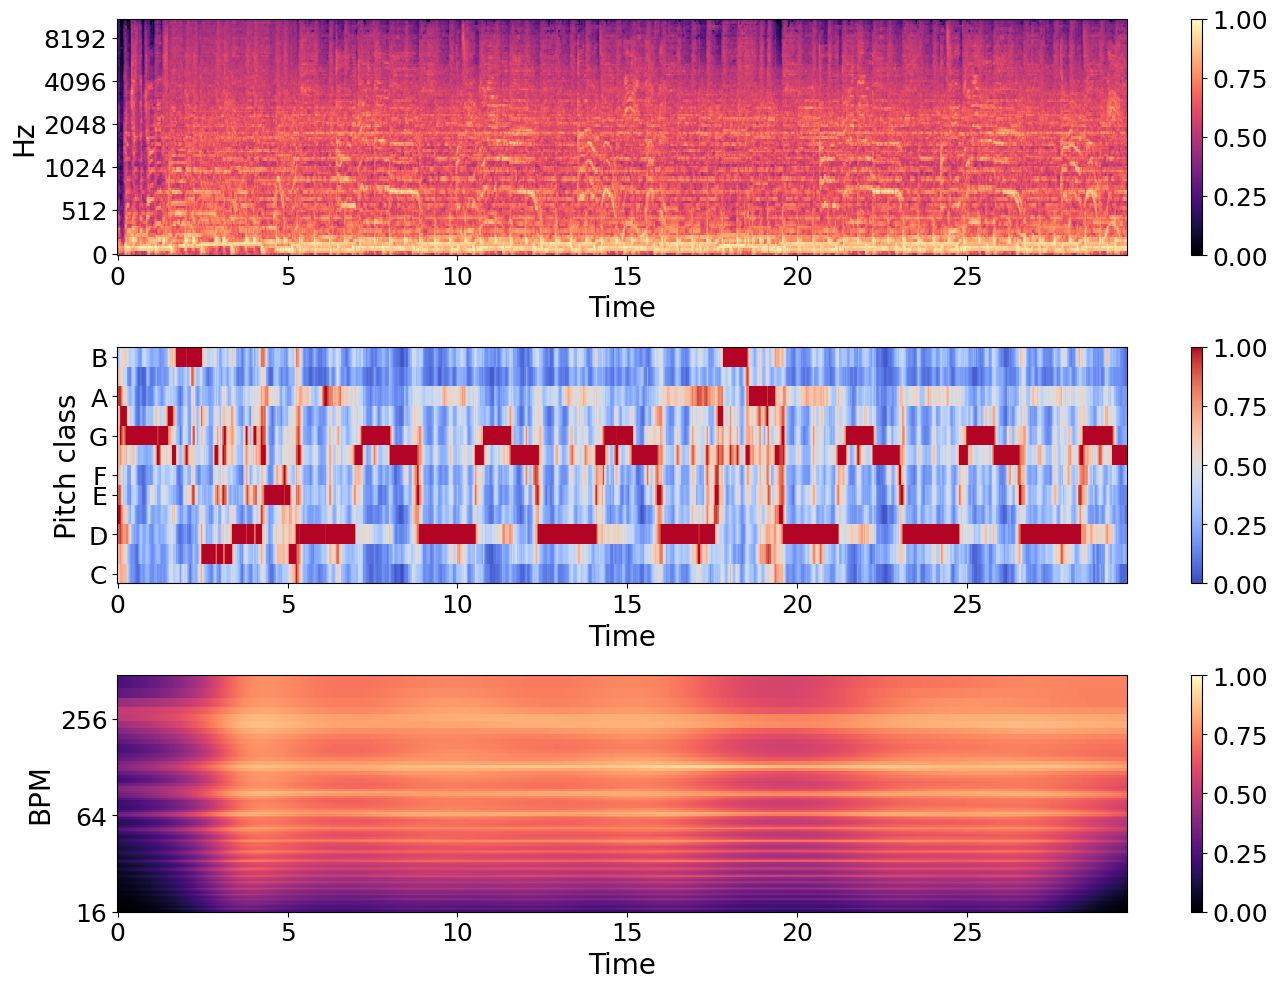

: 

In [ ]:
import h5py
import matplotlib.pyplot as plt
import librosa
import numpy as np

H5_PATH = "../Dataset/spotify_dataset_compressed.h5"  # vagy spotify_dataset.h5

# Ezeket a paramétereket pontosan ugyanúgy kell megadni, ahogy generáltad!
SR = 22050
HOP_LENGTH = 512

with h5py.File(H5_PATH, "r") as hf:
    idx = 100
    mel = hf["spectrograms/mel"][idx]
    chroma = hf["spectrograms/chroma"][idx]
    tempogram = hf["spectrograms/tempogram"][idx]

plt.rc('axes', labelsize=20)    
plt.rc('xtick', labelsize=18)   
plt.rc('ytick', labelsize=18)   
plt.rc('axes', titlesize=20)

# Érdemes egy nagy, közös ábrát csinálni a 3-nak, hogy lásd az időbeli egyezéseket
plt.figure(figsize=(14, 10))

# 1. Mel spektrogram
plt.subplot(3, 1, 1)
# Az imshow helyett specshow-t használunk. A 'magma' színséma nagyon jól mutat audiónál.
librosa.display.specshow(mel, sr=SR, hop_length=HOP_LENGTH, x_axis='time', y_axis='mel', cmap='magma')
plt.colorbar(format='%0.2f') # A "dB" feliratot levettük, mert az adatod 0 és 1 között van!

# 2. Chroma
plt.subplot(3, 1, 2)
# A chroma tengelye automatikusan C, C#, D, stb. hangokra fog változni
librosa.display.specshow(chroma, sr=SR, hop_length=HOP_LENGTH, x_axis='time', y_axis='chroma', cmap='coolwarm')
plt.colorbar(format='%0.2f')

# 3. Tempogram
plt.subplot(3, 1, 3)
# A tempogram tengelye automatikusan BPM-et fog mutatni
librosa.display.specshow(tempogram, sr=SR, hop_length=HOP_LENGTH, x_axis='time', y_axis='tempo', cmap='magma')
plt.colorbar(format='%0.2f')

plt.tight_layout()
plt.show()